# **MLP predictor for ECH index**

Here's an outline of what I want to do:
 - Download the data for ECH from Yahoo Finance, just as they do in the paper, for the same time span and 6 fundamental indicators.
 - Preprocess the data like the paper does
 - Assign a class like they do in the paper with the Gamma function:
+1 if the open price increased, -1 if it decreased.
 - Compute the extra technical indicators using Pandas TA
 - Clean and normalise the dataset. Careful not to normalise the class of course.
 - Calculate the Pearson correlation between each technical indicator and the class.
 - Select the top 10 indicators according to the highest correlation scores. This set will be called "top_10". Make a list of them and print it.
 - Use the top_10 set to train an MLP neural network in a 10-fold cross-validation setup.
 - Assess the accruacy of the MLP model with every partition and find the average accurace across all 10 folds. Report this as the average accuracy of the MLP model.
 - Produce graphs and tables that visualise our resutls and the information we have used and obtained.

Things that I have pending to do:

- ☐ Download the data with _download_history_Polygon.py_ and load it from the local store (ArcticDB) rather than using yfinance

- ☐ Use "Adj Close" or create an "Adj Open", rather than "Open" for Signal – "Open" deosn't consider splits (nor dividends).

- ☑ Fix the scaling/normalisation to happen in the MLP call and not before – ie avoid lookahead bias because of prior scaling knowing future data.

- ☐ Use different Signal function: {+1,0}, {+1,0,-1}, {+1,-1}, {0,-1}. 
See which one makes stronger returns.

- ☐ When using k-fold CV, try time-series k-fold as well as shuffled.

- ☐ Use different correlation measures. Currently using ANOVA F-statistic, but could try Pearson correlation, Spearman correlation, etc.

- ☐ The paper used some specifications for the MLP. Understand them and test whether they would improve the performance.



<!-- 
- ☐ pending task
- ☑ completed task
 -->

##### ########## **STRONG CAVEAT** ########## ##########
This model makes a prediction after the close of day $t$, for trading at or before $\text{Open}_{t+1}$.

It is not valid if the model is supposed to predict during or before day $t$, because features use $\text{Close}_t$, $\text{High}_t$, and $\text{Low}_t$ to be calculated – all of which are recorded after the market closes.

### ---- Initialisation ----

In [1]:
# ======================================
# Initialisation -- import libraries
# ======================================

# Core
import numpy as np
import pandas as pd
import time

# Data download
import yfinance as yf

# Technical indicators
# !pip install pandas-ta   # May need to install it first   ------ IGNORE FOR PYTHON 3.11 ------
# !pip install pandas-ta-classic --quiet   # May need to install this too
# !pip install TA-Lib --quiet     # May need to install this too
# import pandas_ta as ta                                  # ------ IGNORE FOR PYTHON 3.11 ------
import pandas_ta_classic as ta

# Machine learning
from sklearn.model_selection import KFold, cross_val_score
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif

# Feature analysis
from scipy.stats import pearsonr

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# Plot style (publication-like, clean)
sns.set_theme(style="darkgrid", context="talk")

### ---- Download data ----

In [2]:
# =========================
# Download ECH data
# =========================

# Specify ticker and time frame
ticker = "ECH"
start_date = "2008-01-01"
end_date = "2020-01-01"

# Download data from Yahoo Finance
df = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    auto_adjust=False
)

# Since we only download one ETF, remove unnecessary Ticker MultiIndex
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df[["Open", "High", "Low", "Close", "Adj Close", "Volume"]].copy()

# Visualise the data
print("\n", "Data shape:", df.shape)
display(df)

[*********************100%***********************]  1 of 1 completed


 Data shape: (3021, 6)


Price,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2008-01-02,48.549999,48.549999,47.480000,47.610001,31.091810,29800
2008-01-03,47.430000,47.860001,47.349998,47.720001,31.163647,43900
2008-01-04,46.959999,46.959999,46.080002,46.389999,30.295090,15800
2008-01-07,46.150002,46.290001,45.369999,45.590000,29.772654,28100
2008-01-08,45.869999,46.020000,45.360001,45.459999,29.687746,13200
...,...,...,...,...,...,...
2019-12-24,33.549999,33.709999,33.320000,33.490002,26.451027,134300
2019-12-26,33.490002,33.639999,33.369999,33.570000,26.514204,295400
2019-12-27,33.529999,33.650002,33.139999,33.459999,26.427326,209700


### ---- Price history plot ----

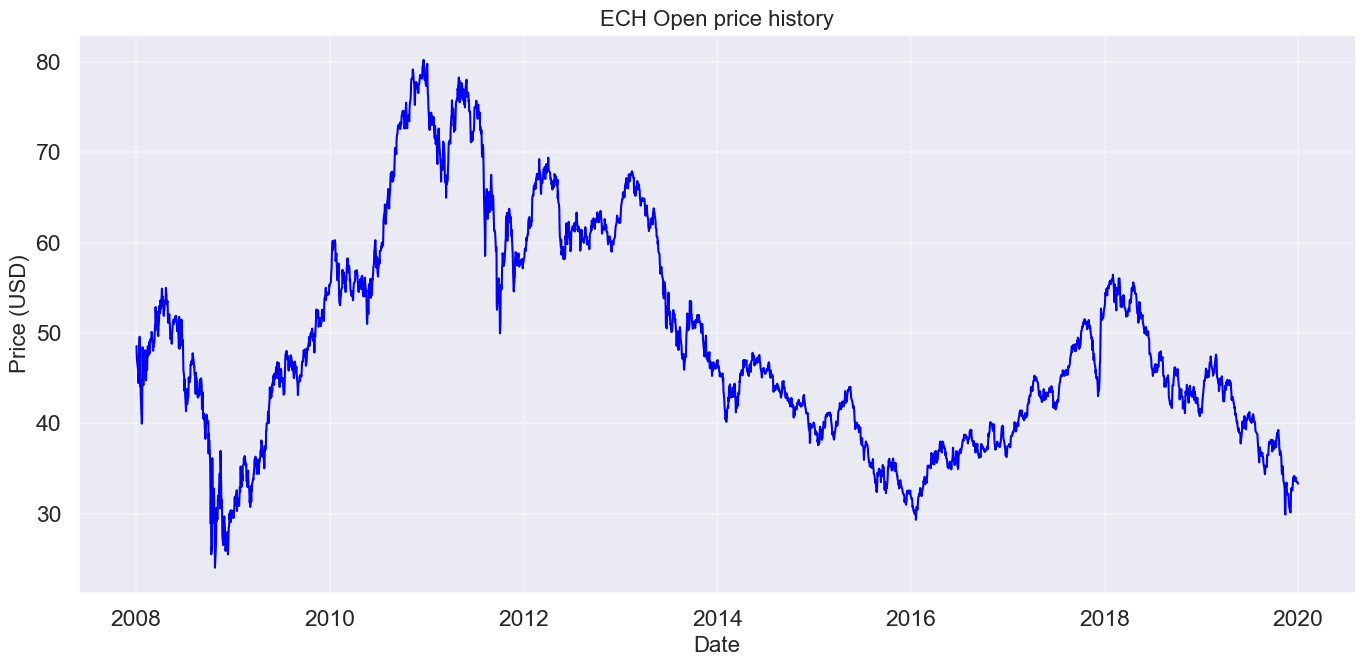

In [3]:
# ==============================================
# Plot ECH price history
# ==============================================

# Plot Open price
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Open'], color='blue', linewidth=1.5)
plt.title(f'{ticker} Open price history', fontsize=16)
plt.xlabel('Date', fontsize=16)
plt.ylabel('Price (USD)', fontsize=16)
plt.grid(True, linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()

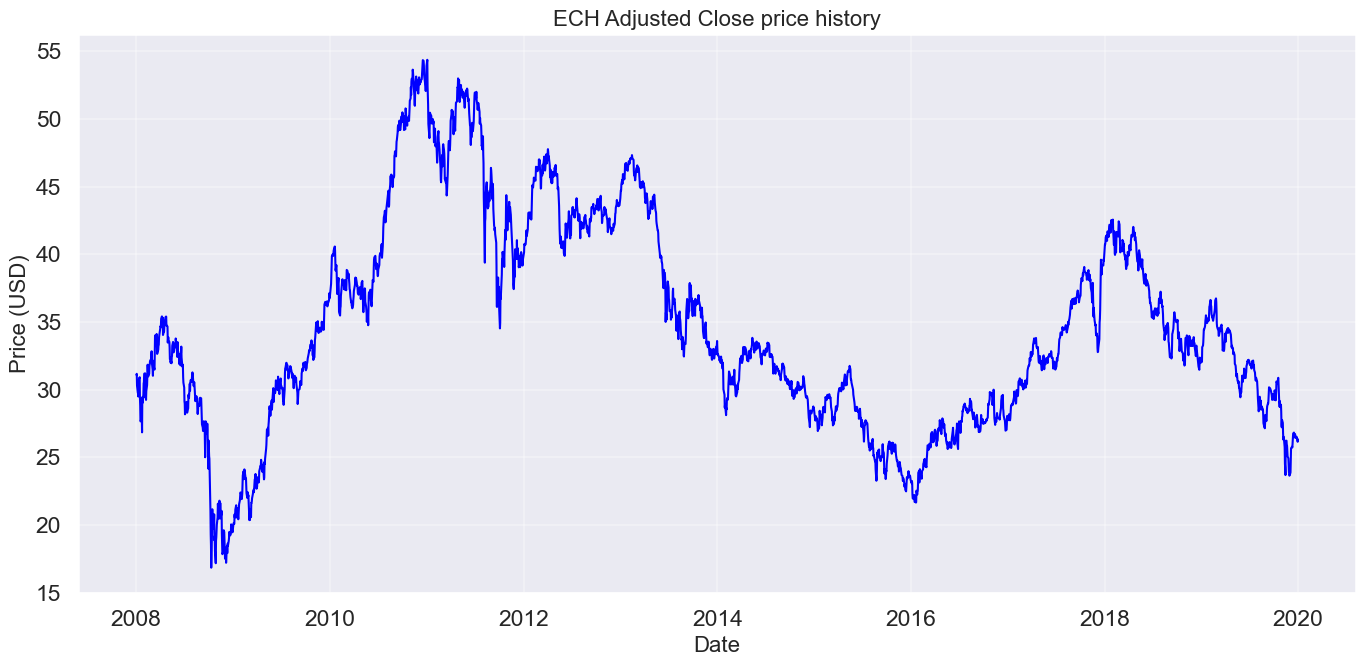

In [4]:
# ==============================================
# Plot ECH price history
# ==============================================

# Plot the Adjusted Close prices
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Adj Close'], color='blue', linewidth=1.5)
plt.title(f'{ticker} Adjusted Close price history', fontsize=16)
plt.xlabel('Date', fontsize=16)
plt.ylabel('Price (USD)', fontsize=16)
plt.grid(True, linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()

### ---- Assign signal ----

Assign a signal to each day of data. 
\begin{equation}
\text{Signal}_t =
\begin{cases}
+1, & \text{if } \text{Open}_{t+1} \geq \text{Open}_t \\
-1, & \text{if } \text{Open}_{t+1} < \text{Open}_t
\end{cases}
\end{equation}
The signal tells us whether we the position should be long (+1) or short (-1).

##### ########## **STRONG CAVEAT** ########## ##########
This model makes a prediction after the close of day $t$, for trading at or before $\text{Open}_{t+1}$.

It is not valid if the model is supposed to predict during or before day $t$, because features (like `BOP`) use $\text{Close}_t$, $\text{High}_t$, and $\text{Low}_t$ to be calculated – all of which are recorded after the market closes.

In [5]:
# =========================
# Assign signal
# =========================

# Compute next day's Open
df["Open_next"] = df["Open"].shift(-1)

# Assign signal: +1 if Open_{t+1} >= Open_t, else -1
df["Signal"] = np.where(df["Open_next"] >= df["Open"], 1, -1)

# Cumulative signal
df["Signal_cum"] = df["Signal"].cumsum() #+ 1  # +1 to counter the initial row being -1

# Visualise
display(df)

Price,Open,High,Low,Close,Adj Close,Volume,Open_next,Signal,Signal_cum
Date,,,,,,,,,
2008-01-02,48.549999,48.549999,47.480000,47.610001,31.091810,29800,47.430000,-1,-1
2008-01-03,47.430000,47.860001,47.349998,47.720001,31.163647,43900,46.959999,-1,-2
2008-01-04,46.959999,46.959999,46.080002,46.389999,30.295090,15800,46.150002,-1,-3
2008-01-07,46.150002,46.290001,45.369999,45.590000,29.772654,28100,45.869999,-1,-4
2008-01-08,45.869999,46.020000,45.360001,45.459999,29.687746,13200,44.450001,-1,-5
...,...,...,...,...,...,...,...,...,...
2019-12-24,33.549999,33.709999,33.320000,33.490002,26.451027,134300,33.490002,-1,31
2019-12-26,33.490002,33.639999,33.369999,33.570000,26.514204,295400,33.529999,1,32
2019-12-27,33.529999,33.650002,33.139999,33.459999,26.427326,209700,33.410000,-1,31


##### Cumulative Gamma plot

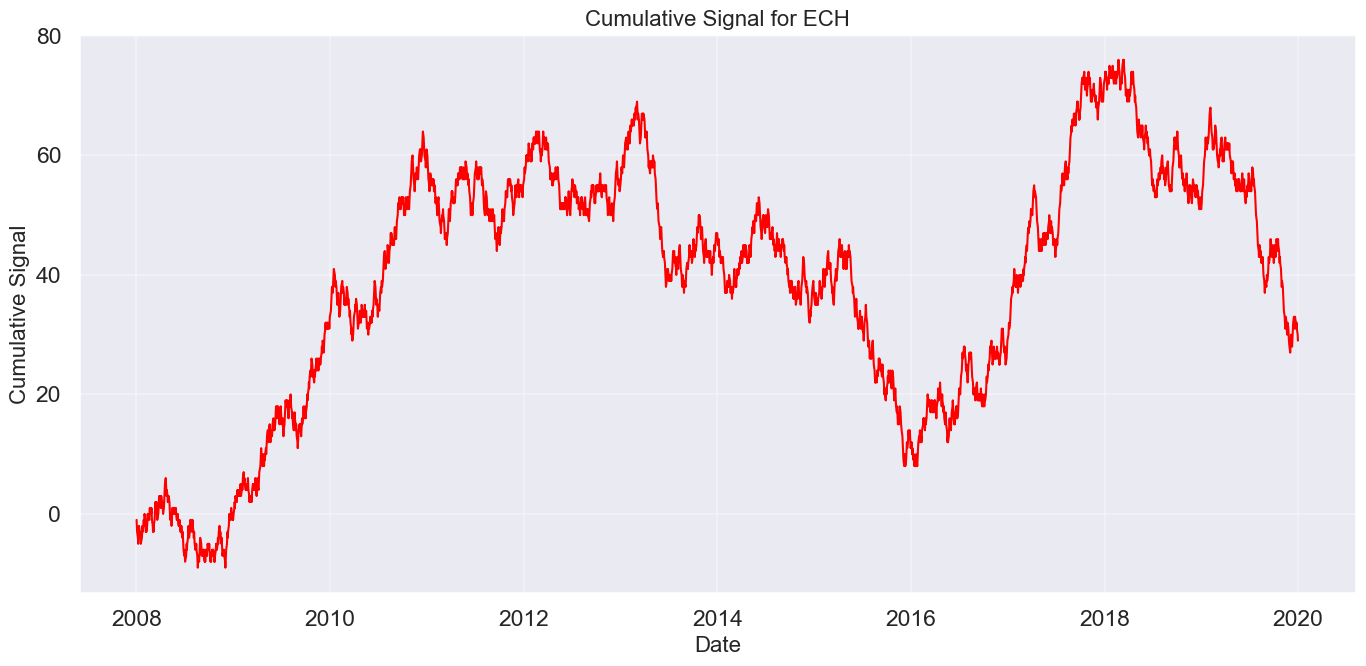

In [6]:
# ==============================================
# Plot Cumultaive Signal
# ==============================================

# Plot the Adjusted prices
plt.figure(figsize=(14, 7))
plt.plot(df.index, df["Signal_cum"], color='red', linewidth=1.5)
plt.title(rf'Cumulative Signal for {ticker}', fontsize=16)
plt.xlabel('Date', fontsize=16)
plt.ylabel(r'Cumulative Signal', fontsize=16)
plt.grid(True, linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()

### ---- Compute technical indicators with Pandas-TA ----

In [7]:
# ==================================================================
# Compute all technical indicators with Pandas-TA and TA-Lib
# ==================================================================

# Run "study" to compute and append all available technical indicators.
df.ta.strategy()

# Visualise all technical indicators calculated
display(df)


Price,Open,High,Low,Close,Adj Close,Volume,Open_next,Signal,Signal_cum,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,ACCBM_20,ACCBU_20,ACOS,AD,ADD,ADOSC_3_10,ADX_14,DMP_14,DMN_14,ADXR_14,ALMA_10_6.0_0.85,AMATe_LR_8_21_2,AMATe_SR_8_21_2,AO_5_34,OBV,OBV_min_2,OBV_max_2,OBVe_4,OBVe_12,AOBV_LR_2,AOBV_SR_2,APO_12_26,AROOND_14,AROONU_14,AROONOSC_14,ASIN,ATAN,ATRr_14,AVGPRICE,AVOLUME_20,BBL_5_2.0,BBM_5_2.0,BBU_5_2.0,BBB_5_2.0,BBP_5_2.0,BIAS_SMA_26,BOP,AR_26,BR_26,CCI_14_0.015,CDL_DOJI_10_0.1,CDL_INSIDE,CDL_2CROWS,CDL_3BLACKCROWS,CDL_3INSIDE,CDL_3LINESTRIKE,CDL_3OUTSIDE,CDL_3STARSINSOUTH,CDL_3WHITESOLDIERS,CDL_ABANDONEDBABY,CDL_ADVANCEBLOCK,CDL_BELTHOLD,CDL_BREAKAWAY,CDL_CLOSINGMARUBOZU,CDL_CONCEALBABYSWALL,CDL_COUNTERATTACK,CDL_DARKCLOUDCOVER,CDL_DOJISTAR,CDL_DRAGONFLYDOJI,CDL_ENGULFING,CDL_EVENINGDOJISTAR,CDL_EVENINGSTAR,CDL_GAPSIDESIDEWHITE,CDL_GRAVESTONEDOJI,CDL_HAMMER,CDL_HANGINGMAN,CDL_HARAMI,CDL_HARAMICROSS,CDL_HIGHWAVE,CDL_HIKKAKE,CDL_HIKKAKEMOD,CDL_HOMINGPIGEON,CDL_IDENTICAL3CROWS,CDL_INNECK,CDL_INVERTEDHAMMER,CDL_KICKING,CDL_KICKINGBYLENGTH,CDL_LADDERBOTTOM,CDL_LONGLEGGEDDOJI,CDL_LONGLINE,CDL_MARUBOZU,CDL_MATCHINGLOW,CDL_MATHOLD,CDL_MORNINGDOJISTAR,CDL_MORNINGSTAR,CDL_ONNECK,CDL_PIERCING,CDL_RICKSHAWMAN,CDL_RISEFALL3METHODS,CDL_SEPARATINGLINES,CDL_SHOOTINGSTAR,CDL_SHORTLINE,CDL_SPINNINGTOP,CDL_STALLEDPATTERN,CDL_STICKSANDWICH,CDL_TAKURI,CDL_TASUKIGAP,CDL_THRUSTING,CDL_TRISTAR,CDL_UNIQUE3RIVER,CDL_UPSIDEGAP2CROWS,CDL_XSIDEGAP3METHODS,open_Z_30_1,high_Z_30_1,low_Z_30_1,close_Z_30_1,CE_L_22_3.0,CE_S_22_3.0,CEIL,CFO_9,CG_10,CHOP_14_1_100,CKSPl_10_3_20,CKSPs_10_3_20,CMF_20,CMO_14,COPC_11_14_10,COS,COSH,CPR_TC,CPR_PIVOT,CPR_BC,CPR_R1,CPR_R2,CPR_S1,CPR_S2,CPR_WIDTH,CPR_WIDTH_PCT,CPR_WIDTH_CLASS,CPR_POSITION,Close_X_Close,Close_XA_Close,CTI_12,CVI_10,LDECAY_5,DEC_1,DEMA_10,DIV,DCL_20_20,DCM_20_20,DCU_20_20,DPO_20,DD,DD_PCT,DD_LOG,DSP_14,DX_14,EBSW_40_10,EDECAY_5,EFI_13,EMA_10,EMV,ENTP_10,EOM_14_100000000,ER_10,BULLP_13,BEARP_13,EXP,FISHERT_9_1,FISHERTs_9_1,FLOOR,FOSC_14,FWMA_10,HA_open,HA_high,HA_low,HA_close,HILO_13_21,HILOl_13_21,HILOs_13_21,HL2,HLC3,HMA_10,HT_DCPERIOD,HT_DCPHASE,HT_PHASOR_INPHASE,HT_PHASOR_QUAD,HT_SINE,HT_LEADSINE,HT_TRENDLINE,HT_TRENDMODE,HVOL_20,HWM,HWU,HWL,HWMA_0.2_0.1_0.1,ISA_9,ISB_26,ITS_9,IKS_26,ICS_26,INC_1,INERTIA_20_14,JMA_7_0,KAMA_10_2_30,KCLe_20_2,KCBe_20_2,KCUe_20_2,K_9_3,D_9_3,J_9_3,KST_10_15_20_30_10_10_10_15,KSTs_9,KURT_30,KVO_34_55_13,KVOs_34_55_13,LAG_1,LR_14,LRa_14,LRb_14,LRm_14,LN,LOG10,LOGRET_1,LRSI_14,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9,MACDEXT_12_26_9,MACDEXTs_12_26_9,MACDEXTh_12_26_9,MACDFIX_9_9,MACDFIXh_9_9,MACDFIXs_9_9,MAD_30,MAMA_0.5_0.05,FAMA_0.5_0.05,MARKETFI,MASSI_9_25,MAVP_2_30,MAXINDEX_30,MCGD_10,MD_30,MEDIAN_30,MEDPRICE,MFI_14,MIDPOINT_2,MIDPRICE_2,MININDEX_30,MIN_30,MAX_30,MINIDX_30,MAXIDX_30,MINUS_DM_14,MMAR_10,MMAR_15,MMAR_20,MMAR_25,MMAR_30,MMAR_35,MOM_10,MSW_SINE_5,MSW_LEAD_5,MULT,NATR_14,ABS,ROUND,NVI_1,OHLC4,PDIST,PCTRET_1,PGO_14,PLUS_DM_14,PMAX_E_10_3.0,PO_14,PPO_12_26_9,PPOh_12_26_9,PPOs_12_26_9,PSARl_0.02_0.2,PSARs_0.02_0.2,PSARaf_0.02_0.2,PSARr_0.02_0.2,PSL_12,PVI_1,PVO_12_26_9,PVOh_12_26_9,PVOs_12_26_9,PVOL,PVR,PVT,PWMA_10,QQE_14_5_4.236,QQE_14_5_4.236_RSIMA,QQEl_14_5_4.236,QQEs_14_5_4.236,QQEb_l_14_5_4.236,QQEb_s_14_5_4.236,QQEd_14_5_4.236,QS_10,QTL_30_0.5,RAINBOW_1,RAINBOW_2,RAINBOW_3,RAINBOW_4,RAINBOW_5,RAINBOW_6,RAINBOW_7,RAINBOW_8,RAINBOW_9,RAINBOW_10,RMA_10,ROC_10,ROCP_10,ROCR_10,ROCR100_10,SUM_30,RSI_14,RSX_14,RVGIh_14_4,RVGI_14_4,RVGIs_14_4,RVI_14,SAREXT,SIN,SINH,SINWMA_14,SKEW_30,SLOPE_1,SMA_10,SMI_5_20_5,SMIs_5_20_5,SMIo_5_20_5,SQRT,SQZ_20_2.0_20_1.5,SQZ_ON,SQZ_OFF,SQZ_NO,SQZPRO_20_2.0_20_2_1.5_1,SQZPRO_ON_WIDE,SQZPRO_ON_NORMAL,SQZPRO_ON_NARROW,SQZPRO_OFF,SQZPRO_NO,SSF_10_2,STC_10_12_26_0.5,STCmacd_10_12_26_0.5,STCstoch_10_12_26_0.5,STDERR_14,STDEV_30,STOCHk_14_3_3,STOCHd_14_3_3,STOCHFk_5_3,STOCHFd_5_3,STOCHRSIk_14_14_3_3,STOCHRSId_14_14_3_3,SUB,SUPERT_7_3.0,SUPERTd_7_3.0,SUPERTl_7_3.0,SUPERTs_7_3.0,SWMA_10,T3_10_0.7,TAN,TANH,TEMA_10,THERM

In [8]:
# ================================================
# List all column names (technical indicators)
# ================================================

cols = df.columns.tolist()

# Find total number of columns (technical indicators) and how many were added by Pandas-TA
n_total = len(cols)
n_added = n_total - 9  # there were already 9 to start with

# Display all column names
print(cols)
# display(pd.DataFrame({"Column": cols}))

print("\n", f"Total number of technical indicators: {n_total}")
print("\n", f"Added TA columns: {n_added}", "\n")


['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Open_next', 'Signal', 'Signal_cum', 'ABER_ZG_5_15', 'ABER_SG_5_15', 'ABER_XG_5_15', 'ABER_ATR_5_15', 'ACCBL_20', 'ACCBM_20', 'ACCBU_20', 'ACOS', 'AD', 'ADD', 'ADOSC_3_10', 'ADX_14', 'DMP_14', 'DMN_14', 'ADXR_14', 'ALMA_10_6.0_0.85', 'AMATe_LR_8_21_2', 'AMATe_SR_8_21_2', 'AO_5_34', 'OBV', 'OBV_min_2', 'OBV_max_2', 'OBVe_4', 'OBVe_12', 'AOBV_LR_2', 'AOBV_SR_2', 'APO_12_26', 'AROOND_14', 'AROONU_14', 'AROONOSC_14', 'ASIN', 'ATAN', 'ATRr_14', 'AVGPRICE', 'AVOLUME_20', 'BBL_5_2.0', 'BBM_5_2.0', 'BBU_5_2.0', 'BBB_5_2.0', 'BBP_5_2.0', 'BIAS_SMA_26', 'BOP', 'AR_26', 'BR_26', 'CCI_14_0.015', 'CDL_DOJI_10_0.1', 'CDL_INSIDE', 'CDL_2CROWS', 'CDL_3BLACKCROWS', 'CDL_3INSIDE', 'CDL_3LINESTRIKE', 'CDL_3OUTSIDE', 'CDL_3STARSINSOUTH', 'CDL_3WHITESOLDIERS', 'CDL_ABANDONEDBABY', 'CDL_ADVANCEBLOCK', 'CDL_BELTHOLD', 'CDL_BREAKAWAY', 'CDL_CLOSINGMARUBOZU', 'CDL_CONCEALBABYSWALL', 'CDL_COUNTERATTACK', 'CDL_DARKCLOUDCOVER', 'CDL_DOJISTAR', 'CDL_DRAGONFLY

### ---- Clean data ----

In [9]:
# ===============================================================
# Find what columns have way too many NaNs to remove them
# ===============================================================

# Percentage of NaNs per column
nan_pct = df.isna().mean().copy() * 100

nan_pct.index.name = 'Tech Indicators NaN % (sorted)'
display(nan_pct.sort_values(ascending=False).head(20))

# Scan thresholds from 0% to 60%
for x in [0, 5, 10, 20, 30, 40, 50]:
    cols = nan_pct[nan_pct > x].index.tolist()

    print(f"\n Number of columns with > {x}% NaNs: {len(cols)}")
    # print(cols)       # Uncomment if you want to see names


Tech Indicators NaN % (sorted)
ASIN                 100.000000
ACOS                 100.000000
QQEs_14_5_4.236       53.459119
PSARs_0.02_0.2        52.565376
SUPERTs_7_3.0         51.539225
QQEl_14_5_4.236       48.891096
SUPERTl_7_3.0         48.692486
PSARl_0.02_0.2        47.467726
HILOs_13_21           42.138365
HILOl_13_21           40.979808
VFI_130                8.639523
TRIXs_30_9             3.177756
TRIX_30_9              2.912943
ISB_26                 2.548825
QQE_14_5_4.236         2.350215
QQEb_s_14_5_4.236      2.317114
QQEb_l_14_5_4.236      2.317114
KVOs_34_55_13          2.184707
TRIXs_18_9             1.986097
TRIXh_18_9             1.986097
dtype: float64


 Number of columns with > 0% NaNs: 254

 Number of columns with > 5% NaNs: 11

 Number of columns with > 10% NaNs: 10

 Number of columns with > 20% NaNs: 10

 Number of columns with > 30% NaNs: 10

 Number of columns with > 40% NaNs: 10

 Number of columns with > 50% NaNs: 5


In [10]:
# ==================================================
# NaN percentage scan (columns)
# ==================================================

run_this_cell = False  # Set to True to run the scan
# run_this_cell = True  # Set to True to run the scan

if run_this_cell:

    # Percentage of NaNs per column
    nan_pct = df.isna().mean().copy() * 100

    # Scan thresholds from 0% to 60% in steps of 5%
    for x in range(0, 60, 5):
        cols = nan_pct[nan_pct <= x].index.tolist()

        print(f"\n Number of columns with <= {x}% NaNs: {len(cols)}")
        # Uncomment if you want to see names
        # print(cols)

After inspecting the columns, we decide to remove all columns with more than 5% NaNs. This way we will drop less rows due to NaNs too.

In [11]:
# ==================================================
# Find the maximum number of NaNs allowed per column
# ==================================================

# Max percentage of NaNs allowed in columns
nan_thresh = 0.05

# Calculate threshold - i.e. minimum number of non-NaNs to keep the column
threshold = int((1 - nan_thresh) * df.shape[0])
print(threshold)

2869


We now proceed to remove/clean any columns with too many NaNs, non-numeric columns and the auxiliary 'Open_next' and 'Signal_cum' columns.

In [12]:
# ====================================================================================================
# Data cleaning – drop columns and rows with too many NaNs, non-numeric and auxiliary columns
# ====================================================================================================

rows_before_cleaning = df.shape[0]
cols_before_cleaning = df.shape[1]

# Drop columns with too many NaNs (e.g. >5%)
df = df.dropna(thresh=threshold, axis=1).copy()

# Drop auxiliary "Open_next" and "Signal_cum" columns
df = df.drop(columns=['Open_next'], errors='ignore').copy()
df = df.drop(columns=['Signal_cum'], errors='ignore').copy()

# Drop non-numeric columns (if any)
df = df.select_dtypes(include=['number']).copy()

cols_after_cleaning = df.shape[1]
cols_removed = cols_before_cleaning - cols_after_cleaning

# Drop rows with any remaining NaNs
df = df.dropna().copy()

rows_after_cleaning = df.shape[0]
rows_cleaned = rows_before_cleaning - rows_after_cleaning

# Visualise
print("\n", cols_removed, "NaN, non-numeric and auxiliary columns have been removed.")
print(rows_cleaned, "rows with NaN have been cleaned.")
print("\n", "We now have", rows_after_cleaning, "rows and", df.shape[1], "columns (features = OHLCaCV + indicators) in the dataset.", "\n")

# display(df)


 15 NaN, non-numeric and auxiliary columns have been removed.
122 rows with NaN have been cleaned.

 We now have 2899 rows and 400 columns (features = OHLCaCV + indicators) in the dataset. 



Next, we want to remove any columns left that have 0 variance (ie. all values are the same). These don't add any information, and would just dump noise on the model.

In [13]:
# ==================================================
# Diagnose and remove globally constant features
# ==================================================

# Identify columns with only one unique value
global_constant_cols = df.columns[df.nunique(dropna=False) <= 1]

# Report how many constant features were found and their unique values
print(f"\n Number of globally constant features: {len(global_constant_cols)}", "\n They will be removed as they provide no information for ML models.")
if len(global_constant_cols) > 0:
    display(pd.DataFrame({
        "Column": global_constant_cols,
        "Unique values": [df[col].unique() for col in global_constant_cols]
    }))

# Drop constant features
df = df.drop(columns=global_constant_cols).copy()

# Visualise
print("\n", "We now have", rows_after_cleaning, "rows and", df.shape[1], "columns (features = OHLCaCV + indicators) in the dataset.", "\n")

# display(df)


 Number of globally constant features: 15 
 They will be removed as they provide no information for ML models.


,Column,Unique values
0,CDL_3STARSINSOUTH,[0.0]
1,CDL_BREAKAWAY,[0.0]
2,CDL_CONCEALBABYSWALL,[0.0]
3,CDL_IDENTICAL3CROWS,[0.0]
4,CDL_KICKING,[0.0]
5,CDL_KICKINGBYLENGTH,[0.0]
6,CDL_MATHOLD,[0.0]
7,CDL_RISEFALL3METHODS,[0.0]
8,Close_X_Close,[1]
9,Close_XA_Close,[0]



 We now have 2899 rows and 385 columns (features = OHLCaCV + indicators) in the dataset. 



### ---- MLP neural network with 10-fold cross-validation ----

Define a function that runs the MLP neural network with 10-fold cross validation and computes the accuracy and computation time for a given number _n_ of top _n_ features.

We ensure there is no lookahead bias by only normalising the data in the training fold for each fold of the process and not beofre giving the data to the model. Moreover, the top _n_ features are selected from the training data and not the whole data.

First, we separate the feature data from the target data.

In [14]:
# =========================
# Feature / target split
# =========================

# Separate features X and target y
X = df.drop(columns=["Signal"]).copy()
y = df["Signal"].copy()

print(f"Feature matrix shape: {X.shape}")
display(X.head(10))
print(f"Target shape: {y.shape}")
display(y.head(10))

Feature matrix shape: (2899, 384)


Price,Open,High,Low,Close,Adj Close,Volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,ACCBM_20,ACCBU_20,AD,ADD,ADOSC_3_10,ADX_14,DMP_14,DMN_14,ADXR_14,ALMA_10_6.0_0.85,AMATe_LR_8_21_2,AMATe_SR_8_21_2,AO_5_34,OBV,OBV_min_2,OBV_max_2,OBVe_4,OBVe_12,AOBV_LR_2,AOBV_SR_2,APO_12_26,AROOND_14,AROONU_14,AROONOSC_14,ATAN,ATRr_14,AVGPRICE,AVOLUME_20,BBL_5_2.0,BBM_5_2.0,BBU_5_2.0,BBB_5_2.0,BBP_5_2.0,BIAS_SMA_26,BOP,AR_26,BR_26,CCI_14_0.015,CDL_DOJI_10_0.1,CDL_INSIDE,CDL_2CROWS,CDL_3BLACKCROWS,CDL_3INSIDE,CDL_3LINESTRIKE,CDL_3OUTSIDE,CDL_3WHITESOLDIERS,CDL_ABANDONEDBABY,CDL_ADVANCEBLOCK,CDL_BELTHOLD,CDL_CLOSINGMARUBOZU,CDL_COUNTERATTACK,CDL_DARKCLOUDCOVER,CDL_DOJISTAR,CDL_DRAGONFLYDOJI,CDL_ENGULFING,CDL_EVENINGDOJISTAR,CDL_EVENINGSTAR,CDL_GAPSIDESIDEWHITE,CDL_GRAVESTONEDOJI,CDL_HAMMER,CDL_HANGINGMAN,CDL_HARAMI,CDL_HARAMICROSS,CDL_HIGHWAVE,CDL_HIKKAKE,CDL_HIKKAKEMOD,CDL_HOMINGPIGEON,CDL_INNECK,CDL_INVERTEDHAMMER,CDL_LADDERBOTTOM,CDL_LONGLEGGEDDOJI,CDL_LONGLINE,CDL_MARUBOZU,CDL_MATCHINGLOW,CDL_MORNINGDOJISTAR,CDL_MORNINGSTAR,CDL_ONNECK,CDL_PIERCING,CDL_RICKSHAWMAN,CDL_SEPARATINGLINES,CDL_SHOOTINGSTAR,CDL_SHORTLINE,CDL_SPINNINGTOP,CDL_STALLEDPATTERN,CDL_STICKSANDWICH,CDL_TAKURI,CDL_TASUKIGAP,CDL_THRUSTING,CDL_TRISTAR,CDL_UNIQUE3RIVER,CDL_UPSIDEGAP2CROWS,CDL_XSIDEGAP3METHODS,open_Z_30_1,high_Z_30_1,low_Z_30_1,close_Z_30_1,CE_L_22_3.0,CE_S_22_3.0,CEIL,CFO_9,CG_10,CHOP_14_1_100,CKSPl_10_3_20,CKSPs_10_3_20,CMF_20,CMO_14,COPC_11_14_10,COS,COSH,CPR_TC,CPR_PIVOT,CPR_BC,CPR_R1,CPR_R2,CPR_S1,CPR_S2,CPR_WIDTH,CPR_WIDTH_PCT,CTI_12,CVI_10,LDECAY_5,DEC_1,DEMA_10,DCL_20_20,DCM_20_20,DCU_20_20,DPO_20,DD,DD_PCT,DD_LOG,DSP_14,DX_14,EBSW_40_10,EDECAY_5,EFI_13,EMA_10,EMV,ENTP_10,EOM_14_100000000,ER_10,BULLP_13,BEARP_13,EXP,FISHERT_9_1,FISHERTs_9_1,FLOOR,FOSC_14,FWMA_10,HA_open,HA_high,HA_low,HA_close,HILO_13_21,HL2,HLC3,HMA_10,HT_DCPERIOD,HT_DCPHASE,HT_PHASOR_INPHASE,HT_PHASOR_QUAD,HT_SINE,HT_LEADSINE,HT_TRENDLINE,HT_TRENDMODE,HVOL_20,HWM,HWU,HWL,HWMA_0.2_0.1_0.1,ISA_9,ISB_26,ITS_9,IKS_26,ICS_26,INC_1,INERTIA_20_14,JMA_7_0,KAMA_10_2_30,KCLe_20_2,KCBe_20_2,KCUe_20_2,K_9_3,D_9_3,J_9_3,KST_10_15_20_30_10_10_10_15,KSTs_9,KURT_30,KVO_34_55_13,KVOs_34_55_13,LAG_1,LR_14,LRa_14,LRb_14,LRm_14,LN,LOG10,LOGRET_1,LRSI_14,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9,MACDEXT_12_26_9,MACDEXTs_12_26_9,MACDEXTh_12_26_9,MACDFIX_9_9,MACDFIXh_9_9,MACDFIXs_9_9,MAD_30,MAMA_0.5_0.05,FAMA_0.5_0.05,MARKETFI,MASSI_9_25,MAVP_2_30,MAXINDEX_30,MCGD_10,MD_30,MEDIAN_30,MEDPRICE,MFI_14,MIDPOINT_2,MIDPRICE_2,MININDEX_30,MIN_30,MAX_30,MINIDX_30,MAXIDX_30,MINUS_DM_14,MMAR_10,MMAR_15,MMAR_20,MMAR_25,MMAR_30,MMAR_35,MOM_10,MSW_SINE_5,MSW_LEAD_5,MULT,NATR_14,ABS,ROUND,NVI_1,OHLC4,PDIST,PCTRET_1,PGO_14,PLUS_DM_14,PMAX_E_10_3.0,PO_14,PPO_12_26_9,PPOh_12_26_9,PPOs_12_26_9,PSARaf_0.02_0.2,PSARr_0.02_0.2,PSL_12,PVI_1,PVO_12_26_9,PVOh_12_26_9,PVOs_12_26_9,PVOL,PVR,PVT,PWMA_10,QQE_14_5_4.236,QQE_14_5_4.236_RSIMA,QQEb_l_14_5_4.236,QQEb_s_14_5_4.236,QQEd_14_5_4.236,QS_10,QTL_30_0.5,RAINBOW_1,RAINBOW_2,RAINBOW_3,RAINBOW_4,RAINBOW_5,RAINBOW_6,RAINBOW_7,RAINBOW_8,RAINBOW_9,RAINBOW_10,RMA_10,ROC_10,ROCP_10,ROCR_10,ROCR100_10,SUM_30,RSI_14,RSX_14,RVGIh_14_4,RVGI_14_4,RVGIs_14_4,RVI_14,SAREXT,SIN,SINH,SINWMA_14,SKEW_30,SLOPE_1,SMA_10,SMI_5_20_5,SMIs_5_20_5,SMIo_5_20_5,SQRT,SQZ_20_2.0_20_1.5,SQZ_ON,SQZ_OFF,SQZPRO_20_2.0_20_2_1.5_1,SQZPRO_ON_WIDE,SQZPRO_ON_NORMAL,SQZPRO_ON_NARROW,SQZPRO_OFF,SSF_10_2,STC_10_12_26_0.5,STCmacd_10_12_26_0.5,STCstoch_10_12_26_0.5,STDERR_14,STDEV_30,STOCHk_14_3_3,STOCHd_14_3_3,STOCHFk_5_3,STOCHFd_5_3,STOCHRSIk_14_14_3_3,STOCHRSId_14_14_3_3,SUPERT_7_3.0,SUPERTd_7_3.0,SWMA_10,T3_10_0.7,TAN,TEMA_10,THERMO_20_2_0.5,THERMOma_20_2_0.5,THERMOl_20_2_0.5,THERMOs_20_2_0.5,TODEG,TORAD,TOS_STDEVALL_LR,TOS_STDEVALL_L_1,TOS_STDEVALL_U_1,TOS_STDEVALL_L_2,TOS_STDEVALL_U_2,TOS_STDEVALL_L_3,TOS_STDEVALL_U_3,TRIMA_10,TRIX_30_9,TRIXs_30_9,TRIX_18_9,TRIXs_18_9,TRIXh_18_9,TRUERANGE_1,TRUNC,TSF_14,TSI_13_25_13,TSIs_13_25_13,TTM_TRND_6,TYPPRICE,UI_14,UO_7_14_28,VAR_30,VHF_28,VIDYA_14,VTXP_14,VTX

Target shape: (2899,)


Date
2008-05-20    1
2008-05-21   -1
2008-05-22    1
2008-05-23   -1
2008-05-27    1
2008-05-28   -1
2008-05-29    1
2008-05-30   -1
2008-06-02   -1
2008-06-03    1
Name: Signal, dtype: int64

Next, we define the function to run the mlp model for the top _n_ features.

It includes a "Pipeline" which, for each fold, scales/normalises the data and selects the top _n_ features only from the training data and not from the testing data.

The top _n_ features are selected using ANOVA F-statistics as suggested by ChatGPT. `f_classif` measures how strongly each feature separates the two classes.

Roughly, the ANOVA F-statistic behaves like

\begin{equation}
F \sim \frac{\text{between-class variance}}{\text{within-class variance}}
\end{equation}

Higher $F$ values indicate stronger class discrimination.

This is similar in spirit to correlation ranking, but integrated safely into the cross-validation pipeline.

In [15]:
def run_mlp_for_top_n(X=X, y=y, n_features=10, verbose=True, random_state = 42, max_iter=1000, number_of_folds=10):
    
    # Start timer
    start_time = time.time()

    # =========================
    # Safety check
    # =========================

    # n_features cannot exceed number of available columns
    if n_features > X.shape[1]:
        raise ValueError(
            f"n_features ({n_features}) cannot be larger than "
            f"the number of available features ({X.shape[1]})."
        )

    # =====================================
    # MLP + 10-fold cross-validation
    # =====================================

    # MLP model with feature selection and scaling in a pipeline for each fold
    pipe = Pipeline([
        ("scaler", MinMaxScaler()),
        ("selector", SelectKBest(score_func=f_classif, k=n_features)),
        ("mlp", MLPClassifier(random_state=random_state, max_iter=max_iter))
    ])

    # K-fold cross-validation – the number of folds is 10 by default
    kf = KFold(n_splits=number_of_folds, shuffle=True, random_state=random_state)
    
    # This runs the whole k-fold c-v training and testing
    cv_scores = cross_val_score(pipe, X, y, cv=kf, scoring="accuracy") 
    # Accuracy scores
    median_accuracy_pct = np.median(cv_scores) * 100
    elapsed_time = time.time() - start_time

    fold_results_df = pd.DataFrame({ "Fold": range(1, number_of_folds + 1), "Accuracy": cv_scores }).set_index("Fold")

    if verbose:
        print("\n")
        print(f"Using top {n_features} features,")
        # display(results_df)
        print(f"median accuracy: {median_accuracy_pct:.2f} %, ")
        print(f"time taken: {elapsed_time:.2f} s")

    return fold_results_df, median_accuracy_pct, elapsed_time

Run the MLP for a varying number of n_features

In [16]:
# =========================
# Run over n_features
# =========================

results = []

# Define feature grid to sweep
n_features_list = (
    list(range(1, 10)) +
    list(range(10, 100, 5)) +
    list(range(100, X.shape[1], 25)) +
    [X.shape[1]]
)
# n_features_list = [1,2,3,4]              # uncomment for little test
# n_features_list = [10, 50, X.shape[1]]   # uncomment for little test

total = len(n_features_list)

# Start total timer
start_total = time.time()

# Loop over varying n_features
for i, n in enumerate(n_features_list, 1):

    _, median_acc, time_elapsed = run_mlp_for_top_n(X, y, n, verbose=False)

    results.append({
        "Top features": n,
        "Median accuracy (%)": round(median_acc, 2),
        "Comp time (s)": round(time_elapsed, 1)
    })

    # Progress update
    print(f"\rProgress: {i}/{total}. Last elapsed time: {time_elapsed:.1f} s.", end="")


# Convert results to DataFrame
results_df = pd.DataFrame(results).set_index("Top features")

# Total elapsed time
total_elapsed = time.time() - start_total
print("\n")
print(f"Total time: {int(total_elapsed//60)} min {int(total_elapsed%60)} s\n")

# Visualise
print("\n", "Results:", "\n")
display(results_df)


/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [52] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [100] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [61] are constant.
 

Progress: 1/40. Last elapsed time: 5.4 s.

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [52] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [100] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [61] are constant.
 

Progress: 2/40. Last elapsed time: 5.8 s.

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [52] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [100] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [61] are constant.
 

...

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [52] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [100] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [61] are constant.
 

Progress: 39/40. Last elapsed time: 131.0 s.

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [52] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [100] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [61] are constant.
 

Progress: 40/40. Last elapsed time: 141.6 s.

Total time: 50 min 40 s


 Results: 



,Median accuracy (%),Comp time (s)
Top features,,
1,80.52,5.4
2,79.83,5.8
3,79.66,5.5
4,80.17,5.0
5,79.66,6.1
6,80.17,7.2
7,79.83,6.8
8,79.48,8.6
9,80.00,7.3


### ---- Plot accuracy and computation time ----

In [17]:
# # ==================================================
# # Plot accuracy vs number of features
# # ==================================================

# # Style
# sns.set_theme(style="darkgrid")

# # Data
# x = results_df.index.astype(str)   # treat as categorical (discrete)
# y = results_df["Median accuracy (%)"]

# # Plot
# plt.figure(figsize=(10, 5))
# plt.plot(x, y, marker='o')

# # Labels
# plt.xlabel("Number of Top Features")
# plt.ylabel("Median Accuracy (%)")
# plt.title("Accuracy vs Number of Top Features")

# # Improve readability
# # plt.xticks(rotation=45)

# plt.tight_layout()
# plt.show()

In [18]:
# # ==================================================
# # Plot computation time vs number of features
# # ==================================================

# import matplotlib.pyplot as plt
# import seaborn as sns

# # Style
# sns.set_theme(style="darkgrid")

# # Data (categorical x-axis)
# x = results_df.index.astype(str)
# y = results_df["Comp time (s)"]

# # Plot
# plt.figure(figsize=(10, 5))
# plt.plot(x, y, marker='o')

# # Labels
# plt.xlabel("Number of Top Features")
# plt.ylabel("Computation Time (s)")
# plt.title("Computation Time vs Number of Top Features")

# # Improve readability
# plt.xticks(rotation=45)

# plt.tight_layout()
# plt.show()

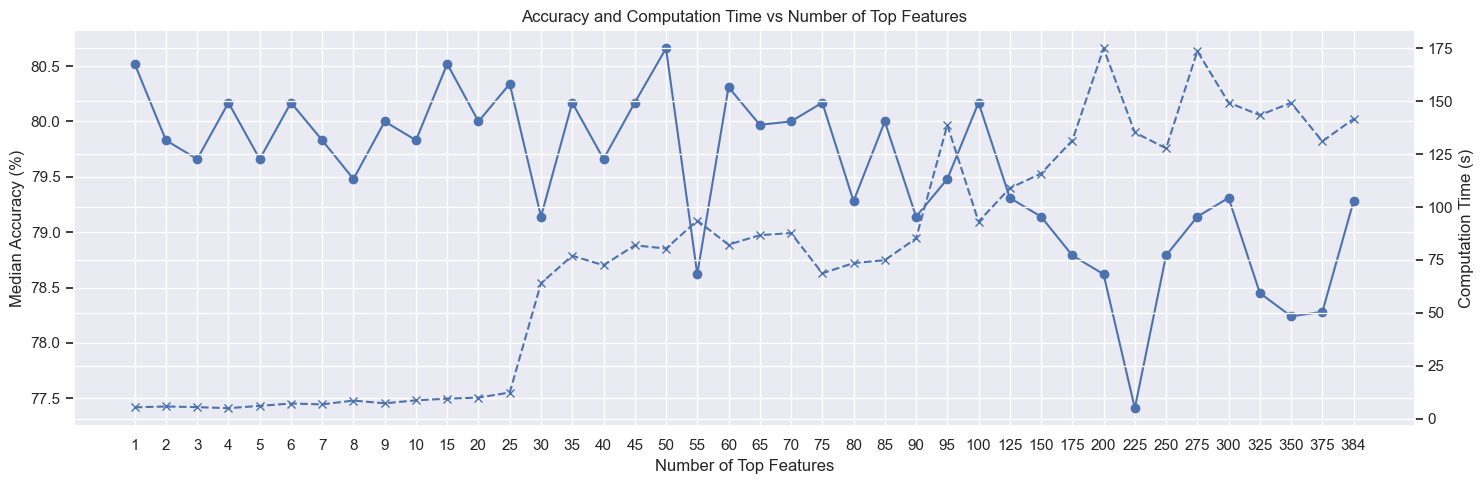

In [22]:
# ==================================================
# Plot accuracy + computation time (dual axis)
# ==================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set_theme(style="darkgrid")

# Data (categorical x-axis)
x = results_df.index.astype(str)
y_acc = results_df["Median accuracy (%)"]
y_time = results_df["Comp time (s)"]

# Create figure
fig, ax1 = plt.subplots(figsize=(15, 5))

# Left axis: accuracy
ax1.plot(x, y_acc, marker='o')
ax1.set_xlabel("Number of Top Features")
ax1.set_ylabel("Median Accuracy (%)")

# Right axis: time
ax2 = ax1.twinx()
ax2.plot(x, y_time, linestyle='--', marker='x')
ax2.set_ylabel("Computation Time (s)")

# Title and formatting
plt.title("Accuracy and Computation Time vs Number of Top Features")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

By analysing the results, we can see that

In [20]:
# ==================================================
# Feature selection frequency across CV folds
# ==================================================

# Find n_features with highest median accuracy
best_n = results_df["Median accuracy (%)"].idxmax()
best_acc = results_df.loc[best_n, "Median accuracy (%)"]

# Rebuild target explicitly and align it to X
target = df["Signal"].loc[X.index]

# Make sure these are the same as used in run_mlp_for_top_n earlier
random_state = 42
number_of_folds = 10

# Same CV split used in run_mlp_for_top_n
kf = KFold(n_splits=number_of_folds, shuffle=True, random_state=random_state)

# Store selected features and their fold-level F-statistics
selected_feature_records = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X), 1):

    # Training data for this fold only
    X_train = X.iloc[train_idx]
    y_train = target.iloc[train_idx]

    # Same preprocessing + selector as in the pipeline
    selector_pipe = Pipeline([
        ("scaler", MinMaxScaler()),
        ("selector", SelectKBest(score_func=f_classif, k=best_n))
    ])

    # Fit only on the training fold
    selector_pipe.fit(X_train, y_train)

    # Extract selected feature names and F-statistics
    selector = selector_pipe.named_steps["selector"]
    selected_mask = selector.get_support()

    selected_features = X.columns[selected_mask]
    selected_scores = selector.scores_[selected_mask]

    # Save selected features and scores
    for feature, score in zip(selected_features, selected_scores):
        selected_feature_records.append({
            "Fold": fold,
            "Feature": feature,
            "ANOVA F-score": score
        })

# Count how often each feature was selected and average its F-statistic
feature_frequency_df = (
    pd.DataFrame(selected_feature_records)
    .groupby("Feature", as_index=False)
    .agg(
        **{
            "Selection count": ("Feature", "count"),
            "Mean ANOVA F-score": ("ANOVA F-score", "mean")
        }
    )
)

# Add frequency as percentage of folds
feature_frequency_df["Selection frequency (%)"] = (
    100 * feature_frequency_df["Selection count"] / kf.get_n_splits()
)

# Sort by selection count, then by mean F-statistic
feature_frequency_df = (
    feature_frequency_df
    .sort_values(
        ["Selection count", "Mean ANOVA F-score"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

# Count fully stable and partially selected features
n_selected_all_folds = (feature_frequency_df["Selection count"] == kf.get_n_splits()).sum()
n_selected_partial = (feature_frequency_df["Selection count"] < kf.get_n_splits()).sum()

# Output
print("\n", f"Best number of features: {best_n}")
print(f"Median accuracy: {best_acc:.2f} %")
print(f"Features selected in all folds: {n_selected_all_folds}")
print(f"Features selected only partially: {n_selected_partial}")

print(
    "\nFeature selection frequency across CV folds:"
    "\nCaveat: this table shows how often each feature was selected across folds. "
    "The F-statistic shown is the average ANOVA F-statistic across the folds "
    "where that feature was selected, not an MLP feature importance.\n"
)

display(feature_frequency_df)


 Best number of features: 50
Median accuracy: 80.66 %
Features selected in all folds: 48
Features selected only partially: 4

Feature selection frequency across CV folds:
Caveat: this table shows how often each feature was selected across folds. The F-statistic shown is the average ANOVA F-statistic across the folds where that feature was selected, not an MLP feature importance.



/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [52] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [100] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [61] are constant.
 

,Feature,Selection count,Mean ANOVA F-score,Selection frequency (%)
0,BOP,10,1848.824365,100.0
1,INC_1,10,647.689265,100.0
2,DEC_1,10,634.908936,100.0
3,SLOPE_1,10,569.362177,100.0
4,BBP_5_2.0,10,541.007445,100.0
5,STOCHFk_5_3,10,528.487576,100.0
6,PCTRET_1,10,512.705188,100.0
7,LOGRET_1,10,510.810040,100.0
8,CDL_LONGLINE,10,500.571473,100.0
9,CDL_BELTHOLD,10,479.091267,100.0
